# <span style="color:green"> Numerical Simulation Laboratory (NSL)
#### Emma Franco
## <span style="color:blue">  Lecture 5</span>
### <span style= "color: black" > Es05.1


In questo esercizio si consederano lo stato fondamentale $1s$ (*100*) e uno dei tre stati eccitati $2p$ (*210*) di un elettrone di un atomo di idrogeno. Questi autostati sono descritti dalle seguenti funzioni d’onda in coordinate sferiche:

$$
\Psi_{1,0,0}(r,\theta,\phi)=
\frac{a_0^{-3/2}}{\sqrt{\pi}} e^{-r/a_0} 
$$

$$
\Psi_{2,1,0}(r,\theta,\phi)=
\frac{a_0^{-5/2}}{8}\sqrt{\frac{2}{\pi}} r e^{-r/2a_0} \cos(\theta)
$$

L'obiettivo è campionare le distribuzioni di probabilità dei due stati, $|\Psi_{1,0,0}(x,y,z)|^2$ e $|\Psi_{2,1,0}(x,y,z)|^2$, in coordinate cartesiane
$$
|\Psi_{1,0,0}(x,y,z)|^2 =
\frac{1}{\pi a_0^3}
e^{-2\frac{\sqrt{x^2+y^2+z^2}}{a_0}}
\qquad
|\Psi_{2,1,0}(x,y,z)|^2 =
\frac{1}{32\pi a_0^5}
z^2
e^{-\frac{\sqrt{x^2+y^2+z^2}}{a_0}}
$$)

,per poi stimare $\left\langle r \right\rangle_{\Psi_{1,0,0}}$ e $\left\langle r \right\rangle_{\Psi_{2,1,0}}$, i cui valori esatti sono rispettivamente $\frac{3}{2}a_0$ e $5a_0$ ($a_0 = 0.0529$ è il raggio di Bohr).    

Per campionare le distribuzioni di probabilità si utilizza l’**algoritmo di Metropolis** ed il metodo delle medie a blocchi, con $10^6$ *lanci* totali divisi in $100$ blocchi statistici.    

L’algoritmo di Metropolis parte da una posizione $\vec{r_{old}}=(x_{\text{old}}, y_{\text{old}}, z_{\text{old}})$ e propone una nuova posizione $\vec{r_{new}}=(x_{\text{new}}, y_{\text{new}}, z_{\text{new}})$ sulla base della probabilità di transizione $T(\vec{r_{old}}|\vec{r_{new}})$. La mossa viene poi accettata con probabilità

$$
A(\vec{r_{old}} \to \vec{r_{new}}) =
\min\left\{1, \frac{T(\vec{r_{old}}|\vec{r_{new}})p(\vec{r_{new}})}{T(\vec{r_{new}}|\vec{r_{old}})p(\vec{r_{old}})}\right\}.
$$

In questo caso si considerano probabilità di transizione simmetriche, cioè

$$
T(\vec{r_{old}}|\vec{r_{new}}) = T(\vec{r_{new}}|\vec{r_{old}}),
$$

per cui la probabilità di accettazione diventa

$$
A(\vec{r_{old}} \to \vec{r_{new}}) =
\min\left\{1, \frac{p(\vec{r_{new}})}{p(\vec{r_{old}})}\right\}.
$$

Inizialmente si utilizza una probabilità di transizione **uniforme** $T(\vec{y}|\vec{x})$; successivamente viene utilizzata una probabilità di transizione **normale multivariata** $T(\vec{y}|\vec{x})$, cioè una gaussiana indipendente per ciascuna coordinata.

Nel caso di transizione uniforme, le nuove coordinate sono estratte indipendentemente in un cubo centrato in $\vec{r}_{\text{old}}$ e di lato $\delta$:

$$
x_{\text{new}} \sim U\left(x_{\text{old}}-\frac{\delta}{2}, x_{\text{old}}+\frac{\delta}{2}\right),
$$

$$
y_{\text{new}} \sim U\left(y_{\text{old}}-\frac{\delta}{2}, y_{\text{old}}+\frac{\delta}{2}\right),
$$

$$
z_{\text{new}} \sim U\left(z_{\text{old}}-\frac{\delta}{2}, z_{\text{old}}+\frac{\delta}{2}\right).
$$

Nel caso di probabilità di transizione gaussiana, le nuove coordinate sono estratte indipendentemente da distribuzioni gaussiane centrate nelle coordinate del punto corrente e con varianza $\sigma$:

$$
x_{\text{new}} \sim \mathcal{N}(x_{\text{old}}, \sigma^2),
$$

$$
y_{\text{new}} \sim \mathcal{N}(y_{\text{old}}, \sigma^2),
$$

$$
z_{\text{new}} \sim \mathcal{N}(z_{\text{old}}, \sigma^2).
$$

È fondamentale scegliere un passo Metropolis opportuno, in modo da ottenere un tasso di accettazione circa del $50\%$. Se il tasso di accettazione è troppo basso, l’algoritmo diventa inefficiente; se invece è troppo alto, i punti campionati risultano fortemente correlati.

Inoltre, è importante equilibrare il sistema prima di iniziare le misure. In questo caso, il sistema è stato equilibrato per $200000$ step, corrispondenti a $20$ blocchi. Questa procedura permette di scartare le prime configurazioni generate, che in generale possono non essere ancora rappresentative della distribuzione di probabilità corretta. L'equilibrazione è particolarmente utile se partiamo da un punto molto lontano dall'origine (e quindi da una distanza dall'origine molto diversa dalla distanza media che vogliamo campionare).

A scopo esemplificativo di quanto detto nel grafico che segue viene riportato uno zoom dell'andamento del valore istantaneo del raggio $r$ nel caso del ground state $\Psi_{100}$ partendo da $\vec{x}_0=(1.5,0,1000)$ campionato utilizzando una probabilità di transizione $T$ uniforme. I risultati sono plottati in scala logaritmica sull'asse y. 

Dal grafico risulta evidente la presenza di un transiente iniziale in cui i valori del raggio sono errati poiché influenzati dal punto di partenza scelto. 


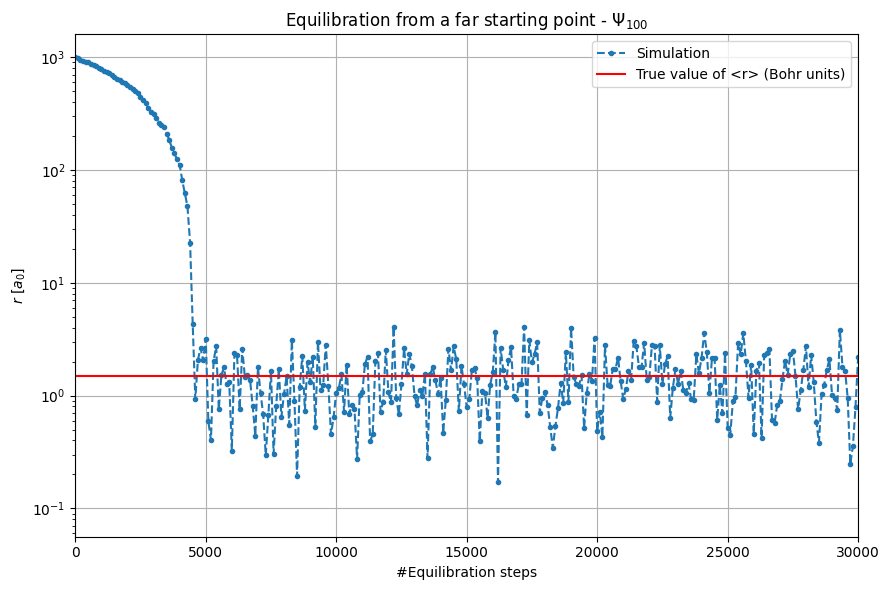

In [1]:
import matplotlib.pyplot as plt
import numpy as np 


def plot(filename, title, x_name, y_name, color, real_value, errorbar=True, logy=False, xlim=None, ax=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 6))
        single_plot = True
    else:
        single_plot = False

    if errorbar:
        x, f, error = np.loadtxt(filename, usecols=(0, 1, 2), unpack=True)
        ax.errorbar(x, f, yerr=error, color=color, label='Simulation')
    else:
        x, f = np.loadtxt(filename, usecols=(0, 1), unpack=True)
        ax.plot(x, f, marker='o', markersize=3, linestyle='--', color=color, label='Simulation')

    ax.axhline(y=real_value, color='r', label='True value of <r> (Bohr units)')
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)
    ax.grid(True)
    ax.set_title(title)
    ax.legend()

    if logy:
        ax.set_yscale("log")

    if xlim is not None:
        ax.set_xlim(xlim)

    if single_plot:
        plt.tight_layout()
        plt.show()


plot("Output/equilibration100_far.txt", r'Equilibration from a far starting point - $\Psi_{100}$', '#Equilibration steps', r'$r$ [$a_0$]', 'C0', 3/2, errorbar=False, logy=True, xlim=(0, 30000))

I punti campionati durante la fase di equilibrazione vengono quindi scartati e non sono utilizzati per il calcolo delle medie finali.

È ragionevole scegliere un punto iniziale vicino alla regione tipica della distribuzione che si vuole campionare. Per questo motivo, sia per la probabilità di transizione uniforme sia per quella gaussiana, sono stati scelti come punti di partenza $\vec{x}_0=(1.5,0,0)$ per lo stato $\Psi_{100}$ e $\vec{x}_0=(0,0,5)$ per lo stato $\Psi_{210}$.

Tuttavia, poiché il numero di step di equilibrazione è considerevole, pari a $200000$, la catena riesce comunque a raggiungere la distribuzione di equilibrio anche partendo da un punto molto lontano. Ad esempio, nel caso dello stato $\Psi_{100}$ con probabilità di transizione uniforme, è stato possibile ottenere risultati corretti anche partendo da $\vec{x}_0=(1.5,0,1000)$, a patto di scartare tutta la fase iniziale di equilibrazione.

Ora vengono riportati i grafici che mostrano $\left\langle r \right\rangle_{\Psi_{1,0,0}}$ e $\left\langle r \right\rangle_{\Psi_{2,1,0}}$, insieme alle rispettive incertezze, in funzione del numero di blocchi. I risultati sono espressi in unità del raggio di Bohr.

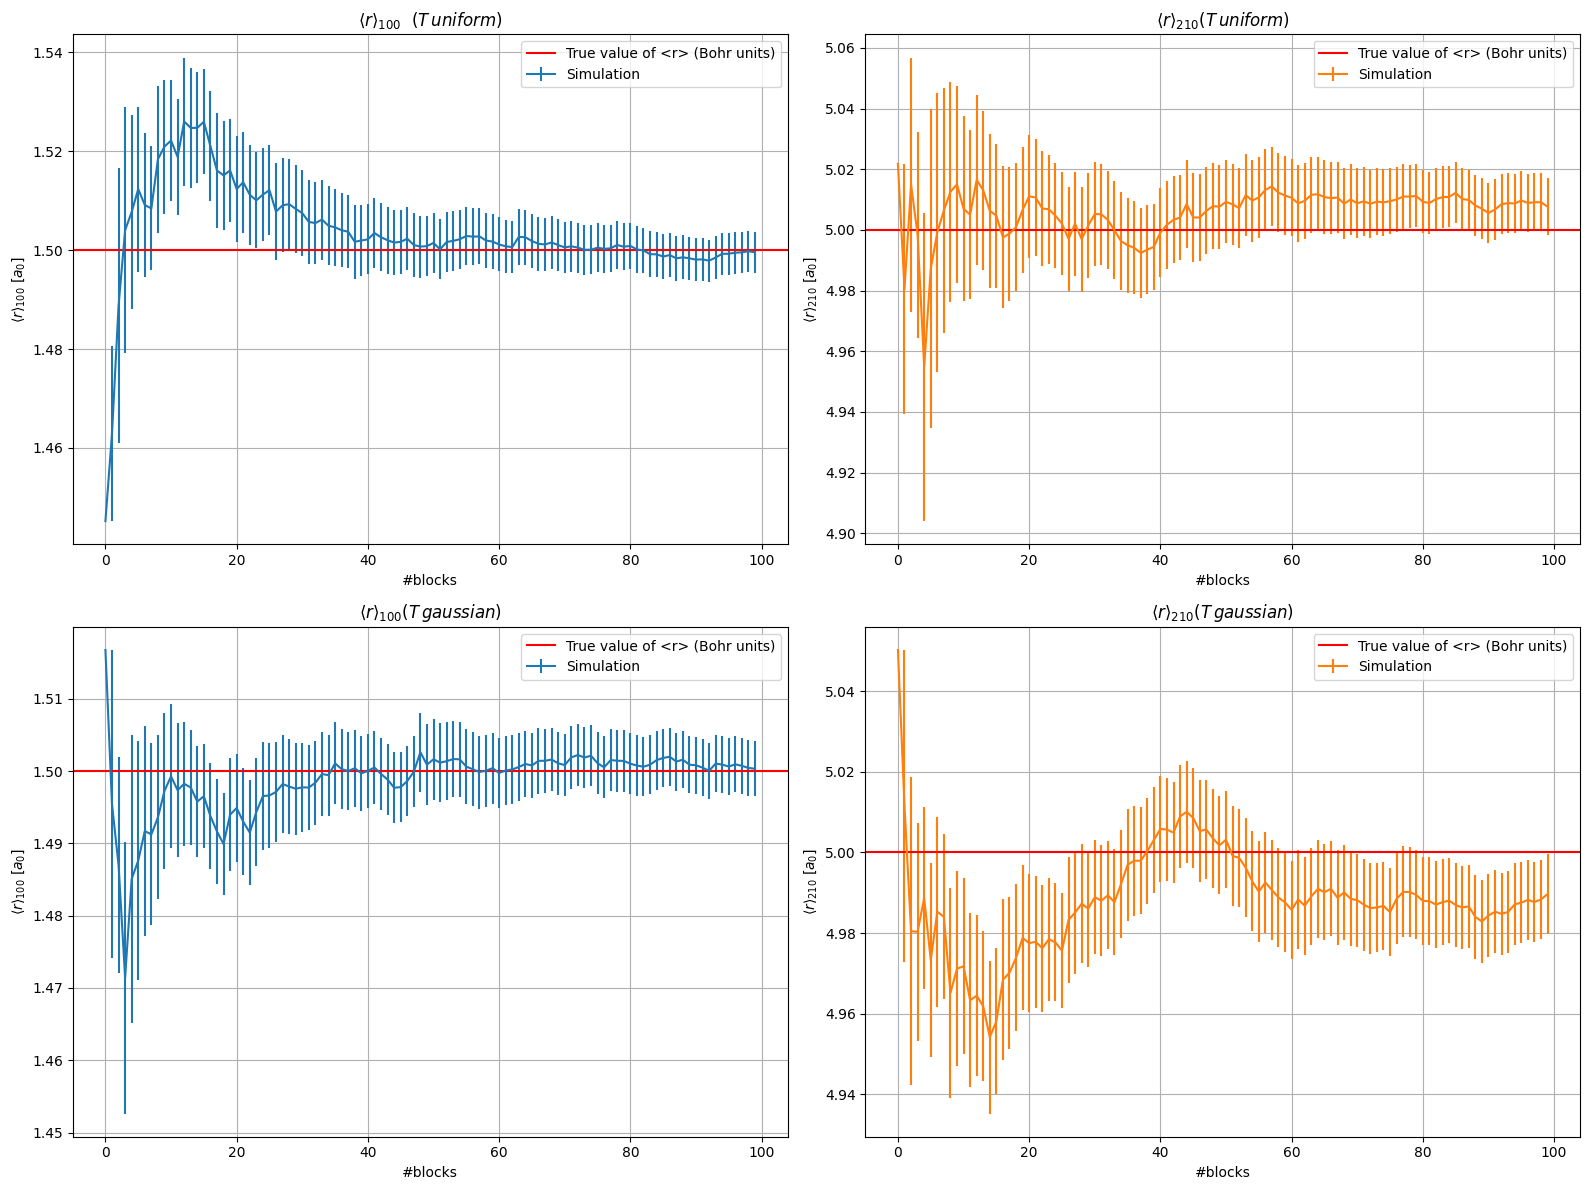

In [4]:

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()

plot("Output/output100.txt", r'$\langle r \rangle_{100}$  $(T  \, uniform)$', '#blocks', r'$\langle r \rangle_{100}$ [$a_0$]', 'C0', 3/2, ax=axs[0] )
plot("Output/output210.txt", r'$\langle r \rangle_{210} (T \, uniform) $', '#blocks', r'$\langle r \rangle_{210}$ [$a_0$]', 'C1', 5, ax=axs[1] )
plot("Output/output100_gauss.txt", r'$\langle r \rangle_{100} (T \, gaussian) $', '#blocks', r'$\langle r \rangle_{100}$ [$a_0$]', 'C0', 3/2, ax=axs[2] )
plot("Output/output210_gauss.txt", r'$\langle r \rangle_{210} (T \, gaussian) $', '#blocks', r'$\langle r \rangle_{210}$ [$a_0$]', 'C1', 5, ax=axs[3] )

plt.tight_layout()
plt.show()

In entrambi i casi, sia con $T$ uniforme sia con $T$ gaussiana, vi è accordo con i valori attesi.

Infine si può osservare come i punti campionati si distirbuiscono nello spazio:

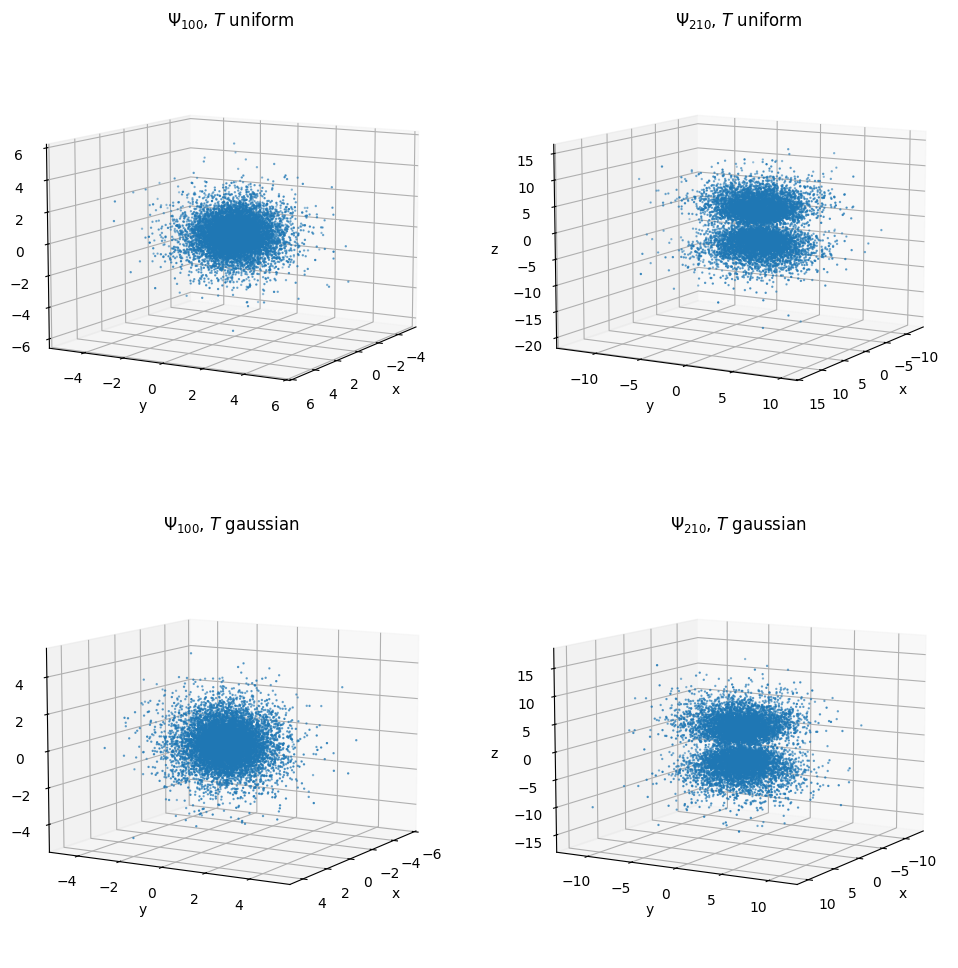

In [35]:

def punti (filename, title):

    fig = plt.figure(figsize=(12, 12))

    for i, (filename, title) in enumerate(zip(files, titles)):

        data = np.loadtxt(filename)

        x = data[:, 0]
        y = data[:, 1]
        z = data[:, 2]


        ax = fig.add_subplot(2, 2, i + 1, projection="3d")

        ax.scatter(x, y, z, s=2, marker=".")
        ax.set_title(title)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("z")
        ax.view_init(10, 30)

    plt.show()

files = ["Output/positions100.txt", "Output/positions210.txt", "Output/positions100_gauss.txt", "Output/positions210_gauss.txt"]
titles = [r"$\Psi_{100}$, $T$ uniform", r"$\Psi_{210}$, $T$ uniform", r"$\Psi_{100}$, $T$ gaussian", r"$\Psi_{210}$, $T$ gaussian"]

punti(files, titles)


Le distribuzioni di punti ottenute nei quattro casi sono coerenti con quanto atteso: per lo stato $\Psi_{100}$ si osserva una distribuzione circa sferica, mentre per lo stato $\Psi_{210}$ si osserva una distribuzione bi-lobata, con un nodo in corrispondenza del piano $z=0$.